# PCOS Research Funding Analysis

Companion notebook to "what nobody funds, women live with" on [The Draft](https://thedraft.substack.com).

This notebook pulls NIH research funding data for Polycystic Ovary Syndrome (PCOS) and several comparison conditions (endometriosis, uterine fibroids, rheumatoid arthritis) from 2014–2024 to examine the structural underfunding of PCOS research relative to its prevalence and disease burden.

**Data source:** [NIH RePORTER API](https://api.reporter.nih.gov/) — the National Institutes of Health's public database of federally funded research projects.

**Contents:**
1. Setup
2. Pulling NIH funding data for PCOS and comparison conditions
3. Manually entering prevalence data
4. Chart — annual funding by condition (2014–2024)
5. Chart — funding per affected person (the headline comparison)
6. Findings

---

## 1. Setup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time

## 2. Pulling NIH funding data for PCOS

I'm using the NIH RePORTER API to pull every NIH-funded research project related to PCOS from 2014 through 2024. For each project, the API returns the year it was funded and the dollar amount awarded. I sum the awards by year to get annual research funding totals.

The function below loops through each fiscal year, queries the API, paginates through results (some years have hundreds of grants), and aggregates the funding.

In [ ]:
def get_funding_by_year(search_term, years=range(2014, 2025)):
    """
    Query NIH RePORTER for total annual funding of a given search term.
    Returns a list of dicts: condition, year, funding_millions, project_count.
    """
    url = "https://api.reporter.nih.gov/v2/projects/search"
    all_data = []

    for year in years:
        all_projects = []
        offset = 0

        # Paginate through results for this year (max 500 per request)
        while True:
            payload = {
                "criteria": {
                    "advanced_text_search": {
                        "operator": "and",
                        "search_field": "all",
                        "search_text": search_term
                    },
                    "fiscal_years": [year]
                },
                "limit": 500,
                "offset": offset
            }

            response = requests.post(url, json=payload)
            if response.status_code != 200:
                print(f"  {year}: failed with status {response.status_code}")
                break

            data = response.json()
            results = data.get('results', [])
            all_projects.extend(results)

            # Stop paginating when we've collected everything
            total_available = data.get('meta', {}).get('total', 0)
            if len(all_projects) >= total_available or len(results) == 0:
                break
            offset += 500
            time.sleep(0.5)

        # Sum award amounts for this year (some entries may be None, default to 0)
        year_funding = sum(p.get('award_amount') or 0 for p in all_projects)

        all_data.append({
            'condition': search_term,
            'year': year,
            'funding_millions': year_funding / 1_000_000,
            'project_count': len(all_projects)
        })

        print(f"  {year}: ${year_funding/1e6:.1f}M ({len(all_projects)} projects)")
        time.sleep(1)  # be nice to the API between years

    return all_data


# Pull PCOS data
print("Pulling PCOS funding data (this will take ~30 seconds)...\n")
pcos_data = get_funding_by_year('polycystic ovary syndrome')

pcos_df = pd.DataFrame(pcos_data)
print(f"\nTotal PCOS projects across 11 years: {pcos_df['project_count'].sum()}")
print(f"Average annual PCOS funding: ${pcos_df['funding_millions'].mean():.1f}M")
print(f"\n{pcos_df}")

Pulling PCOS funding data (this will take ~30 seconds)...

  2014: $16.3M (53 projects)
  2015: $18.4M (54 projects)
  2016: $19.8M (54 projects)
  2017: $29.4M (73 projects)
  2018: $32.6M (76 projects)
  2019: $33.0M (78 projects)
  2020: $34.2M (76 projects)
  2021: $31.9M (83 projects)
  2022: $30.9M (78 projects)
  2023: $33.3M (87 projects)
  2024: $34.5M (77 projects)

Total PCOS projects across 11 years: 789
Average annual PCOS funding: $28.6M

                    condition  year  funding_millions  project_count
0   polycystic ovary syndrome  2014         16.315234             53
1   polycystic ovary syndrome  2015         18.422967             54
2   polycystic ovary syndrome  2016         19.842900             54
3   polycystic ovary syndrome  2017         29.424368             73
4   polycystic ovary syndrome  2018         32.552661             76
5   polycystic ovary syndrome  2019         32.978144             78
6   polycystic ovary syndrome  2020         34.167528       

## 3. Pulling NIH funding data for comparison conditions

To assess whether PCOS is *relatively* underfunded, we need comparison conditions. I'm pulling three:

- **Endometriosis** — another chronic women's health condition with similar prevalence (~10% of reproductive-age women). Useful for showing whether the underfunding pattern extends across women's reproductive health conditions broadly.
- **Rheumatoid arthritis** — a chronic autoimmune condition with comparable disease burden, but affecting both sexes (with a female skew). Frequently cited in the PCOS research literature as a benchmark for "what an appropriately funded chronic condition looks like."
- **Systemic lupus erythematosus (lupus)** — another chronic autoimmune condition predominantly affecting women, with much lower prevalence than PCOS.

These three conditions let us compare PCOS funding across (a) similar women's conditions, (b) similarly-prevalent autoimmune conditions, and (c) much-rarer autoimmune conditions.

I'm using the same function from the previous cell, just calling it with different search terms.

In [ ]:
# Three comparison conditions
comparison_conditions = [
    'endometriosis',
    'rheumatoid arthritis',
    'systemic lupus erythematosus'
]

all_comparison_data = []

for condition in comparison_conditions:
    print(f"\nPulling {condition}...")
    data = get_funding_by_year(condition)
    all_comparison_data.extend(data)

# Combine with PCOS data into a single dataframe
df = pd.concat([pcos_df, pd.DataFrame(all_comparison_data)], ignore_index=True)

# Summary table: average annual funding by condition
print("\n" + "="*60)
print("Average annual NIH funding by condition (2014-2024)")
print("="*60)
summary = df.groupby('condition')['funding_millions'].mean().sort_values(ascending=False)
for condition, funding in summary.items():
    print(f"  {condition}: ${funding:.1f}M/year")

# Total projects per condition for reference
print("\n" + "="*60)
print("Total NIH-funded projects per condition (2014-2024)")
print("="*60)
project_summary = df.groupby('condition')['project_count'].sum().sort_values(ascending=False)
for condition, count in project_summary.items():
    print(f"  {condition}: {count} projects")


Pulling endometriosis...
  2014: $24.6M (87 projects)
  2015: $25.0M (81 projects)
  2016: $22.1M (72 projects)
  2017: $20.8M (66 projects)
  2018: $27.8M (70 projects)
  2019: $33.1M (83 projects)
  2020: $34.8M (76 projects)
  2021: $46.7M (98 projects)
  2022: $52.7M (104 projects)
  2023: $58.2M (124 projects)
  2024: $59.6M (114 projects)

Pulling rheumatoid arthritis...
  2014: $248.8M (568 projects)
  2015: $198.8M (505 projects)
  2016: $250.2M (536 projects)
  2017: $241.1M (519 projects)
  2018: $250.8M (544 projects)
  2019: $246.7M (531 projects)
  2020: $238.0M (536 projects)
  2021: $257.5M (541 projects)
  2022: $257.1M (530 projects)
  2023: $256.9M (491 projects)
  2024: $233.5M (435 projects)

Pulling systemic lupus erythematosus...
  2014: $148.3M (341 projects)
  2015: $138.3M (300 projects)
  2016: $153.2M (334 projects)
  2017: $163.3M (346 projects)
  2018: $372.3M (810 projects)
  2019: $485.2M (980 projects)
  2020: $525.2M (1051 projects)
  2021: $570.5M (11

## 4. Calculating funding per affected person

Total NIH funding is one measure of how seriously a condition is taken, but it's not the only one. A more honest comparison normalizes by how many people the condition actually affects. A condition affecting 10 million people that gets \$100M in research funding is fundamentally different from a condition affecting 100,000 people that gets the same \$100M.

Below I hardcode US prevalence estimates for each condition (from CDC, NIH, and the Lupus Foundation), then calculate annual NIH funding *per affected person*, averaged across 2014–2024.


In [ ]:
# US prevalence estimates (sourced from CDC, NIH, and disease-specific foundations)
# PCOS and endometriosis: among women of reproductive age, ~10% prevalence
# RA and lupus: among all adults
prevalence_us = {
    'polycystic ovary syndrome': 5_000_000,        # ~10% of US women of reproductive age (NIH)
    'endometriosis': 6_500_000,                     # CDC / ACOG estimate
    'rheumatoid arthritis': 1_300_000,              # CDC
    'systemic lupus erythematosus': 322_000         # Lupus Foundation of America (SLE specifically)
}

# Calculate 2014-2024 average funding per affected person for each condition
print("="*65)
print("Annual NIH funding PER AFFECTED PERSON (2014-2024 average)")
print("="*65)

per_person_data = []

for condition in prevalence_us:
    # Average annual funding across all 11 years (in dollars, not millions)
    avg_funding_dollars = df[df['condition'] == condition]['funding_millions'].mean() * 1_000_000
    affected = prevalence_us[condition]
    per_person = avg_funding_dollars / affected

    per_person_data.append({
        'condition': condition,
        'avg_annual_funding_millions': avg_funding_dollars / 1_000_000,
        'us_prevalence': affected,
        'funding_per_person': per_person
    })

    print(f"\n  {condition}")
    print(f"    Avg annual funding: ${avg_funding_dollars/1e6:.1f}M")
    print(f"    US prevalence: {affected:,}")
    print(f"    Per person per year: ${per_person:.2f}")

# Save to dataframe for charting
per_person_df = pd.DataFrame(per_person_data).sort_values('funding_per_person', ascending=False)
print("\n" + "="*65)
print("Sorted (highest funding per person → lowest):")
print("="*65)
print(per_person_df.to_string(index=False))

Annual NIH funding PER AFFECTED PERSON (2014-2024 average)

  polycystic ovary syndrome
    Avg annual funding: $28.6M
    US prevalence: 5,000,000
    Per person per year: $5.72

  endometriosis
    Avg annual funding: $36.9M
    US prevalence: 6,500,000
    Per person per year: $5.67

  rheumatoid arthritis
    Avg annual funding: $243.6M
    US prevalence: 1,300,000
    Per person per year: $187.36

  systemic lupus erythematosus
    Avg annual funding: $387.3M
    US prevalence: 322,000
    Per person per year: $1202.94

Sorted (highest funding per person → lowest):
                   condition  avg_annual_funding_millions  us_prevalence  funding_per_person
systemic lupus erythematosus                   387.345756         322000         1202.937130
        rheumatoid arthritis                   243.564089        1300000          187.356992
   polycystic ovary syndrome                    28.575386        5000000            5.715077
               endometriosis                    36.

## 5. Chart — Annual NIH funding by condition (2014–2024)

This first chart shows the raw annual funding for each condition over time. The vertical scale is in millions of dollars.

What to look for: PCOS and endometriosis sit near the bottom of the chart across the entire decade, while rheumatoid arthritis and lupus operate at an entirely different order of magnitude. The gap isn't subtle — it's structural.

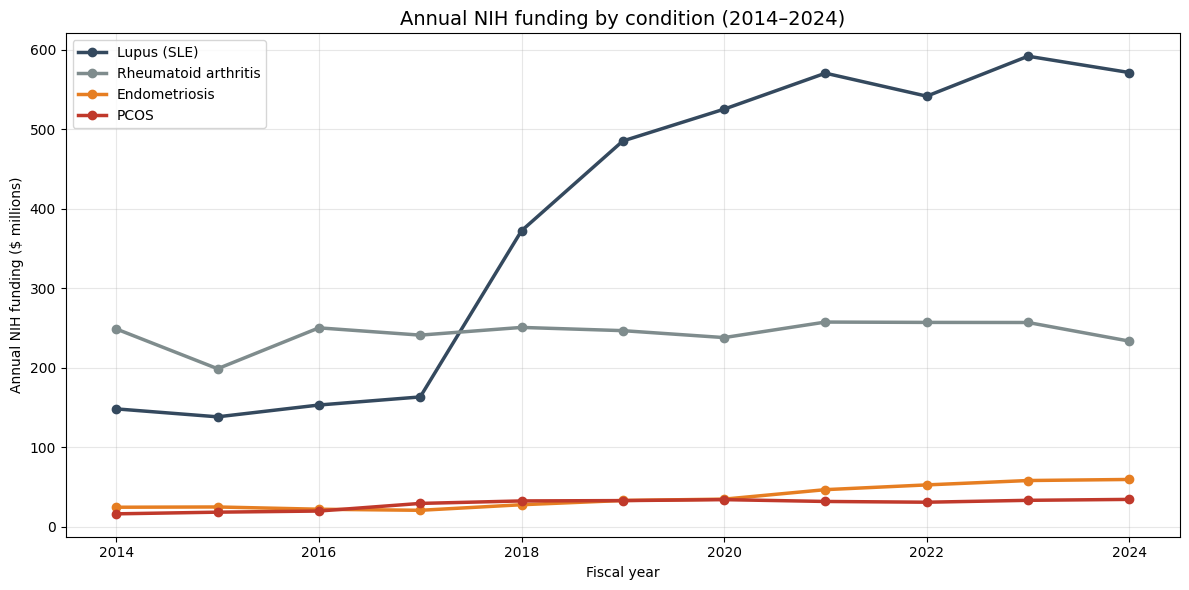

In [ ]:
# Consistent color scheme used across both charts
# PCOS in crimson (the focus condition), endometriosis in orange (parallel women's condition),
# RA and lupus in grays (comparison group)
colors = {
    'polycystic ovary syndrome': '#c0392b',
    'endometriosis': '#e67e22',
    'rheumatoid arthritis': '#7f8c8d',
    'systemic lupus erythematosus': '#34495e'
}

labels = {
    'polycystic ovary syndrome': 'PCOS',
    'endometriosis': 'Endometriosis',
    'rheumatoid arthritis': 'Rheumatoid arthritis',
    'systemic lupus erythematosus': 'Lupus (SLE)'
}

plt.figure(figsize=(12, 6))

# Plot each condition. Order matters for legend readability — highest-funded first.
plot_order = ['systemic lupus erythematosus', 'rheumatoid arthritis',
              'endometriosis', 'polycystic ovary syndrome']

for condition in plot_order:
    subset = df[df['condition'] == condition].sort_values('year')
    plt.plot(subset['year'], subset['funding_millions'],
             marker='o', linewidth=2.5, label=labels[condition],
             color=colors[condition])

plt.title("Annual NIH funding by condition (2014–2024)", fontsize=14)
plt.xlabel("Fiscal year")
plt.ylabel("Annual NIH funding ($ millions)")
plt.legend(loc='upper left', frameon=True)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("chart1_funding_over_time.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Chart — Annual NIH funding per affected person (2014–2024)

This normalizes funding by US prevalence, so it answers the question: *how much does the NIH spend, per year, on research for each person affected by this condition?*

The disparity is the entire point. Two women's reproductive conditions sit at the very bottom of this chart at less than $6/person/year. Rheumatoid arthritis is 30x higher. Lupus is over 200x higher.

This isn't a complexity story; PCOS and rheumatoid arthritis are both chronic, multi-system conditions. It's a structural story about which patient populations get research attention.

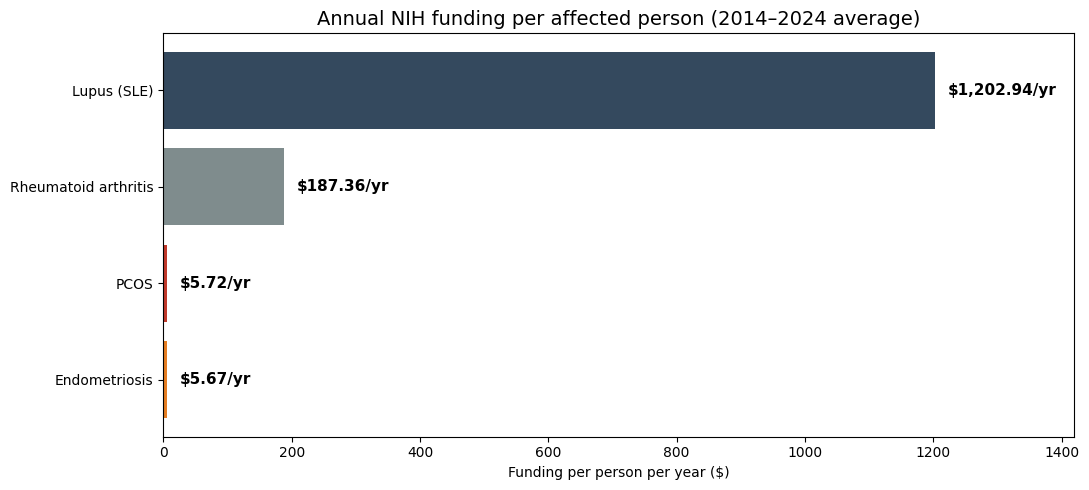

In [ ]:
# Sort smallest to largest so the chart reads top-to-bottom from highest-funded to lowest-funded
# (In matplotlib barh, the first item in the sorted list appears at the bottom of the chart)
plot_data = per_person_df.sort_values('funding_per_person', ascending=True).reset_index(drop=True)
plot_data['display_label'] = plot_data['condition'].map(labels)
bar_colors_ordered = [colors[c] for c in plot_data['condition']]

plt.figure(figsize=(11, 5))
bars = plt.barh(plot_data['display_label'], plot_data['funding_per_person'], color=bar_colors_ordered)

# Add dollar value labels at the end of each bar so the magnitudes are readable
# even for the smallest bars (which will be PCOS and endometriosis)
for bar, value in zip(bars, plot_data['funding_per_person']):
    plt.text(value + 20, bar.get_y() + bar.get_height()/2,
             f"${value:,.2f}/yr", va='center', fontsize=11, fontweight='bold')

plt.title("Annual NIH funding per affected person (2014–2024 average)", fontsize=14)
plt.xlabel("Funding per person per year ($)")
plt.xlim(0, max(plot_data['funding_per_person']) * 1.18)  # add headroom for the labels
plt.tight_layout()
plt.savefig("chart2_funding_per_person.png", dpi=150, bbox_inches='tight')
plt.show()

---

## Findings

**Key observations:**

- PCOS receives the least total NIH funding of the four conditions ($28.6M/year), despite affecting ~5 million US women of reproductive age.
- On a per-affected-person basis, PCOS and endometriosis are essentially tied at the bottom (~\$5.70/year for both), with endometriosis fractionally lower (\$5.67) than PCOS (\$5.72). Each receives roughly 1/33rd of rheumatoid arthritis funding and 1/210th of lupus funding.
- The near-identical per-person numbers for PCOS and endometriosis suggest the underfunding pattern extends across women's reproductive health conditions broadly, not just PCOS specifically.
- Endometriosis funding has grown substantially since 2017 (from \$20.8M to \$59.6M, nearly tripling), while PCOS funding has remained flat at ~\$30M — possibly reflecting differences in patient advocacy momentum between the two conditions.

**Caveat:** Lupus funding shows a notable step-change in 2018 (project count rises from ~340 to ~810 annually), which may reflect either a coordinated NIH initiative beginning that year or search-term breadth catching tangentially-related projects. Rheumatoid arthritis is the cleaner primary comparison; lupus is included for additional context.

**Conclusion:**

The funding disparity isn't explainable by condition complexity (RA and PCOS are both chronic, multi-system disorders) or prevalence (PCOS has the largest affected population in this comparison set). It reflects a structural pattern in how research priorities have historically been set; favoring conditions framed as systemic/autoimmune over conditions framed as reproductive, and favoring patient populations with longer-organized advocacy infrastructure.

See the [accompanying post on TheDraft](https://thedrafthq.substack.com) for the full argument.